In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
print(df.shape)

(167, 10)


In [7]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [8]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [9]:
print(df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.795000    1330.000000

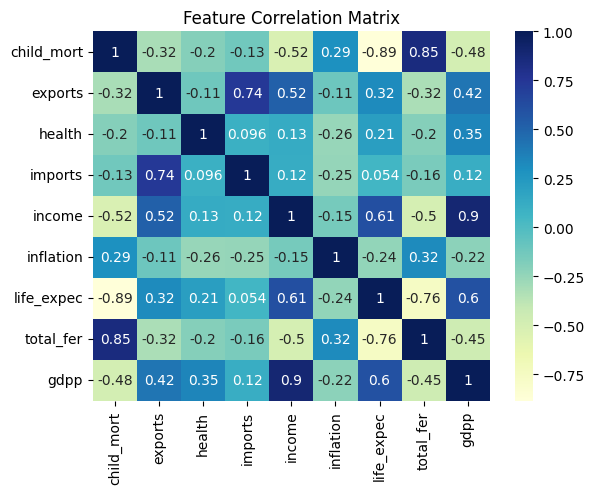

In [10]:
sns.heatmap(df.drop("country", axis=1).corr(),annot=True,
    cmap="YlGnBu"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
features = df.drop("country", axis=1)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

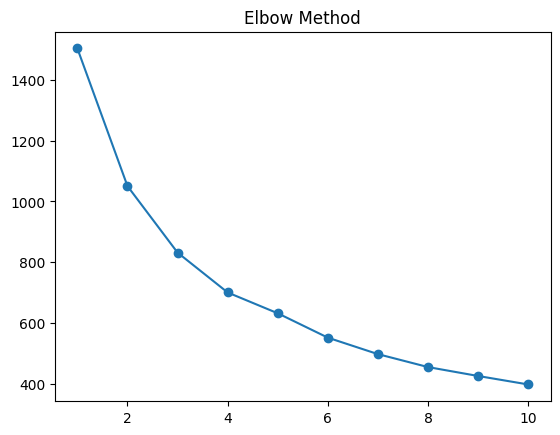

In [12]:
# elbow curve - before kmeans
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=10, n_init=15)
    km.fit(scaled_features)
    wcss.append(km.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans_model = KMeans(n_clusters=3, random_state=10,n_init=15)

df["Segment_ID"] = kmeans_model.fit_predict( scaled_features)

print("\nCluster Counts")
print(df["Segment_ID"].value_counts())


Cluster Counts
Segment_ID
2    84
1    47
0    36
Name: count, dtype: int64


In [14]:

cluster_profile = ( df.groupby("Segment_ID").mean(numeric_only=True))

print("\nCluster Profile")
print(cluster_profile)


Cluster Profile
            child_mort    exports    health    imports        income  \
Segment_ID                                                             
0             5.000000  58.738889  8.807778  51.491667  45672.222222   
1            92.961702  29.151277  6.388511  42.323404   3942.404255   
2            21.927381  40.243917  6.200952  47.473404  12305.595238   

            inflation  life_expec  total_fer          gdpp  
Segment_ID                                                  
0            2.671250   80.127778   1.752778  42494.444444  
1           12.019681   59.187234   5.008085   1922.382979  
2            7.600905   72.814286   2.307500   6486.452381  


In [15]:
dbscan_model = DBSCAN( eps=1.2,min_samples=4)

df["Density_Cluster"] = dbscan_model.fit_predict( scaled_features)

print("\nDBSCAN Results")
print(df["Density_Cluster"].value_counts())


DBSCAN Results
Density_Cluster
 1    76
-1    50
 0    23
 2    18
Name: count, dtype: int64


In [16]:
X = df.drop(["country", "Segment_ID", "Density_Cluster"],   axis=1)

y = df["Segment_ID"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10,
    stratify=y
)

In [17]:
rf_model = RandomForestClassifier(n_estimators=150,max_depth=6,random_state=10)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_predictions)

print("\nRandom Forest Accuracy")
print(rf_accuracy)

print("\nClassification Report")
print( classification_report(  y_test,rf_predictions))


Random Forest Accuracy
0.9705882352941176

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.91      1.00      0.95        10
           2       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [18]:
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=10,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score( y_test, xgb_predictions)

print("\nXGBoost Accuracy")
print(xgb_accuracy)

print("\nClassification Report")
print(classification_report(  y_test,xgb_predictions))


XGBoost Accuracy
0.9705882352941176

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      1.00      1.00        10
           2       1.00      0.94      0.97        17

    accuracy                           0.97        34
   macro avg       0.96      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34




Feature Importance
      Feature  Importance
0  child_mort    0.293940
8        gdpp    0.189733
6  life_expec    0.172256
7   total_fer    0.141548
4      income    0.127307
2      health    0.033727
5   inflation    0.017653
1     exports    0.013899
3     imports    0.009936


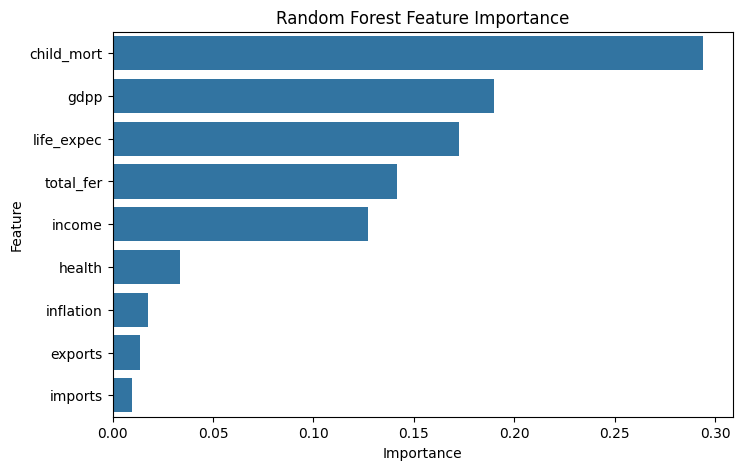

In [19]:
importance_df = pd.DataFrame({"Feature": X.columns,"Importance": rf_model.feature_importances_})

importance_df = importance_df.sort_values(by="Importance",   ascending=False)

print("\nFeature Importance")
print(importance_df)

plt.figure(figsize=(8,5))

sns.barplot( data=importance_df,  x="Importance",y="Feature")

plt.title("Random Forest Feature Importance")
plt.show()

In [20]:
print("Final")

print(f"K-Means Clusters Created : {df['Segment_ID'].nunique()}")

print(f"DBSCAN Clusters Found : " f"{len(set(df['Density_Cluster'])) - (1 if -1 in df['Density_Cluster'].values else 0)}"
)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")
print(f"XGBoost Accuracy       : {xgb_accuracy:.4f}")

if rf_accuracy > xgb_accuracy:
    print("\nBest Performing Model : Random Forest")
else:
    print("\nBest Performing Model : XGBoost")

print("done.")

Final
K-Means Clusters Created : 3
DBSCAN Clusters Found : 3
Random Forest Accuracy : 0.9706
XGBoost Accuracy       : 0.9706

Best Performing Model : XGBoost
done.
